# 8.3. fMRI 3D CNN: Volumetric Deep Learning with Attention

**Learning Objectives:**
- Understand how to apply **3D convolutional neural networks** to fMRI volumes
- Build an end-to-end pipeline from NIfTI volumes to PyTorch tensors
- Learn run-aware train/validation/test splitting to reduce leakage
- Train and evaluate a compact **3D CNN with channel attention** for category decoding
- Compare deep volumetric decoding to the MVPA workflow in **7.2**

**Key Concepts:**
- **3D Convolution**: Filters operate across x, y, z dimensions of brain volumes
- **Volumetric Input**: fMRI samples are 3D brain images (or ROI volumes)
- **Attention (SE block)**: Channel-wise reweighting to emphasize informative feature maps
- **Run-Aware Evaluation**: Keep runs/chunks separated in train and test splits
- **Regularization**: Dropout, weight decay, and early stopping to prevent overfitting

This notebook follows the same Haxby setup from **7.2 fMRI MVPA**, but extends the baseline 3D CNN with a lightweight **attention module**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from nilearn import datasets, image
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Load Haxby Data (faces vs houses)

As in 7.2, we use the Haxby visual object dataset and decode **face vs house**.

To keep training tractable in a tutorial setting, we:
- use one subject
- focus on the **ventral temporal (VT) mask**
- build compact 3D ROI volumes per trial

In [2]:
repo_root = Path("./").resolve().parents[1]
data_dir = repo_root / "datasets" / "fmri_mvpa_haxby"
data_dir.mkdir(parents=True, exist_ok=True)

haxby = datasets.fetch_haxby(data_dir=str(data_dir))

func_img = image.load_img(haxby.func[0])
vt_mask_img = image.load_img(haxby.mask_vt[0])
labels_df = pd.read_csv(haxby.session_target[0], sep=" ")

labels = labels_df["labels"].values
chunks = labels_df["chunks"].values
is_face_house = np.isin(labels, ["face", "house"])

y = (labels[is_face_house] == "face").astype(np.int64)  # face=1, house=0
groups = chunks[is_face_house]

print("Functional image shape:", func_img.shape)
print("VT mask shape:", vt_mask_img.shape)
print("Selected samples (face/house):", len(y))
print("Class balance [house, face]:", np.bincount(y))
print("Unique chunks:", np.unique(groups))

[fetch_haxby] Dataset found in /Users/yibeisita/Documents/neuro-ai-playground/datasets/fmri_mvpa_haxby/haxby2001
Functional image shape: (40, 64, 64, 1452)
VT mask shape: (40, 64, 64)
Selected samples (face/house): 216
Class balance [house, face]: [108 108]
Unique chunks: [ 0  1  2  3  4  5  6  7  8  9 10 11]


## 2. Build Compact 3D Volumes in VT ROI

Raw Haxby volumes are relatively large for a simple tutorial CNN. We reduce the size by:
1. extracting only face/house volumes
2. applying VT mask
3. cropping to the VT bounding box
4. z-scoring each sample volume

Final tensor shape will be `(N, 1, D, H, W)`.

In [3]:
from nilearn.image import index_img

# Select only face/house time points from 4D image
idx = np.where(is_face_house)[0]
func_face_house = index_img(func_img, idx)

# Convert to arrays
X4d = func_face_house.get_fdata()  # shape: (X, Y, Z, N)
mask = vt_mask_img.get_fdata() > 0

# Bounding box of VT mask
coords = np.where(mask)
x_min, x_max = coords[0].min(), coords[0].max() + 1
y_min, y_max = coords[1].min(), coords[1].max() + 1
z_min, z_max = coords[2].min(), coords[2].max() + 1

# Crop mask and data
mask_crop = mask[x_min:x_max, y_min:y_max, z_min:z_max]
X_crop = X4d[x_min:x_max, y_min:y_max, z_min:z_max, :]  # (D,H,W,N)

# Apply mask and stack as samples-first
X_samples = np.transpose(X_crop, (3, 0, 1, 2))  # (N,D,H,W)
X_samples = X_samples * mask_crop[None, ...]

# Per-sample z-score normalization (within ROI voxels)
X_norm = np.zeros_like(X_samples, dtype=np.float32)
mask_flat = mask_crop.reshape(-1)

for i in range(X_samples.shape[0]):
    vol = X_samples[i]
    vox = vol.reshape(-1)[mask_flat]
    mu = vox.mean()
    sd = vox.std() + 1e-6
    vol_z = (vol - mu) / sd
    X_norm[i] = vol_z.astype(np.float32)

# Add channel dimension for CNN: (N,1,D,H,W)
X_3d = X_norm[:, None, :, :, :]

print("Cropped volume shape (D,H,W):", X_3d.shape[2:])
print("Final tensor shape (N,C,D,H,W):", X_3d.shape)

Cropped volume shape (D,H,W): (31, 13, 8)
Final tensor shape (N,C,D,H,W): (216, 1, 31, 13, 8)


## 3. Run-Aware Split (train / val / test)

To avoid run leakage (as discussed in 7.3), we split by **chunks**:
- test = one held-out run
- val = one held-out run from remaining
- train = all other runs

This gives a realistic evaluation and avoids mixing highly correlated samples across splits.

In [4]:
unique_runs = np.unique(groups)
test_run = unique_runs[-1]
val_run = unique_runs[-2]

test_idx = np.where(groups == test_run)[0]
val_idx = np.where(groups == val_run)[0]
train_idx = np.where((groups != test_run) & (groups != val_run))[0]

print(f"Train run IDs: {sorted(set(groups[train_idx]))}")
print(f"Val run ID:    {val_run}")
print(f"Test run ID:   {test_run}")

print(f"Train samples: {len(train_idx)}")
print(f"Val samples:   {len(val_idx)}")
print(f"Test samples:  {len(test_idx)}")

print("Train class balance [house, face]:", np.bincount(y[train_idx]))
print("Val class balance   [house, face]:", np.bincount(y[val_idx]))
print("Test class balance  [house, face]:", np.bincount(y[test_idx]))

Train run IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Val run ID:    10
Test run ID:   11
Train samples: 180
Val samples:   18
Test samples:  18
Train class balance [house, face]: [90 90]
Val class balance   [house, face]: [9 9]
Test class balance  [house, face]: [9 9]


## 4. Dataset, DataLoaders, and 3D CNN Model

In [5]:
class FMRI3DDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = FMRI3DDataset(X_3d[train_idx], y[train_idx])
val_ds = FMRI3DDataset(X_3d[val_idx], y[val_idx])
test_ds = FMRI3DDataset(X_3d[test_idx], y[test_idx])

batch_size = 8
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(f"Batches per epoch (train): {len(train_loader)}")

Batches per epoch (train): 23


In [6]:
class SEBlock3D(nn.Module):
    """Squeeze-and-Excitation block for channel attention in 3D CNNs."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(4, channels // reduction)
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1, 1)
        return x * w


class Simple3DCNNWithAttention(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),
        )

        self.block2 = nn.Sequential(
            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),
        )

        self.block3 = nn.Sequential(
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
        )

        self.attn = SEBlock3D(64, reduction=8)
        self.global_pool = nn.AdaptiveAvgPool3d((1, 1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.attn(x)  # channel attention
        x = self.global_pool(x)
        x = self.classifier(x)
        return x


model = Simple3DCNNWithAttention(n_classes=2).to(device)
print(model)

Simple3DCNN(
  (features): Sequential(
    (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool3d(output_size=(1, 1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_feature

## 5. Training and Validation

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * Xb.size(0)
        total_correct += (preds == yb).sum().item()
        total_n += Xb.size(0)

    return total_loss / total_n, total_correct / total_n


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            logits = model(Xb)
            loss = criterion(logits, yb)

            preds = logits.argmax(dim=1)
            total_loss += loss.item() * Xb.size(0)
            total_correct += (preds == yb).sum().item()
            total_n += Xb.size(0)

    return total_loss / total_n, total_correct / total_n

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

n_epochs = 20
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_state = None

for epoch in range(1, n_epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_accs.append(tr_acc)
    val_accs.append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = model.state_dict()

    print(f"Epoch {epoch:02d} | "
          f"Train loss: {tr_loss:.3f}, acc: {tr_acc:.3f} | "
          f"Val loss: {va_loss:.3f}, acc: {va_acc:.3f}")

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nRestored best model with val acc = {best_val_acc:.3f}")

Epoch 01 | Train loss: 0.713, acc: 0.517 | Val loss: 0.835, acc: 0.500
Epoch 02 | Train loss: 0.714, acc: 0.478 | Val loss: 0.704, acc: 0.500
Epoch 03 | Train loss: 0.699, acc: 0.550 | Val loss: 0.701, acc: 0.500
Epoch 04 | Train loss: 0.703, acc: 0.550 | Val loss: 0.708, acc: 0.500
Epoch 05 | Train loss: 0.704, acc: 0.539 | Val loss: 0.721, acc: 0.500
Epoch 06 | Train loss: 0.709, acc: 0.478 | Val loss: 0.816, acc: 0.500
Epoch 07 | Train loss: 0.701, acc: 0.517 | Val loss: 0.702, acc: 0.500
Epoch 08 | Train loss: 0.706, acc: 0.556 | Val loss: 0.696, acc: 0.500
Epoch 09 | Train loss: 0.710, acc: 0.511 | Val loss: 0.761, acc: 0.500
Epoch 10 | Train loss: 0.693, acc: 0.500 | Val loss: 0.693, acc: 0.333
Epoch 11 | Train loss: 0.705, acc: 0.467 | Val loss: 0.695, acc: 0.500
Epoch 12 | Train loss: 0.692, acc: 0.539 | Val loss: 0.697, acc: 0.500
Epoch 13 | Train loss: 0.693, acc: 0.550 | Val loss: 0.696, acc: 0.500
Epoch 14 | Train loss: 0.686, acc: 0.561 | Val loss: 1.356, acc: 0.500
Epoch 

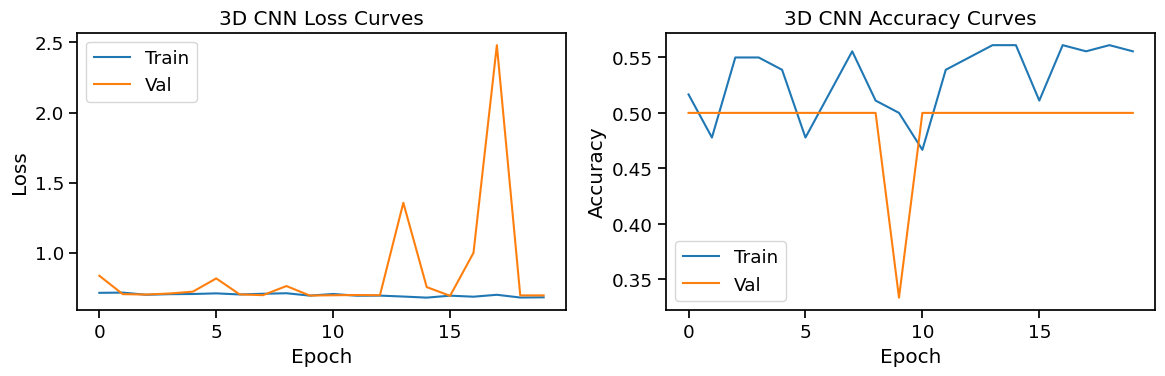

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses, label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('3D CNN Loss Curves')
axes[0].legend()

axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs, label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('3D CNN Accuracy Curves')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Test Evaluation

In [10]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

model.eval()
all_true, all_pred = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = model(Xb)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_pred.append(pred)
        all_true.append(yb.numpy())

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

cm = confusion_matrix(all_true, all_pred)
print("\nConfusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(all_true, all_pred, target_names=['house', 'face']))

Test loss: 0.685
Test accuracy: 0.500

Confusion matrix:
[[9 0]
 [9 0]]

Classification report:
              precision    recall  f1-score   support

       house       0.50      1.00      0.67         9
        face       0.00      0.00      0.00         9

    accuracy                           0.50        18
   macro avg       0.25      0.50      0.33        18
weighted avg       0.25      0.50      0.33        18



## 7. Improving Accuracy

If your accuracy is lower than expected, try:

- **Better evaluation design**: Use full `LeaveOneGroupOut` over chunks and average results
- **More data**: Include more subjects and train subject-generalizable models
- **Input design**: Try whole-brain low-res volumes vs ROI-only patches
- **Model upgrades**: Residual 3D blocks, attention pooling, or hybrid 3D CNN + temporal models
- **Hyperparameter tuning**: Learning rate, batch size, weight decay, dropout, epochs
- **Class balancing**: Weighted loss if class counts differ across splits
- **Statistical validation**: Add permutation testing (as in 7.2/7.3)

This notebook provides a compact baseline. In real research settings, robust performance comes from
careful CV design, larger datasets, and stronger architectures.